# is the point reyes water level or the salinity stations time serieses strongly autocorrelated?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.signal import find_peaks, correlate, correlation_lags, find_peaks_cwt
from scipy.integrate import trapz
from datetime import datetime, timedelta
from vtools.functions.filter import cosine_lanczos
from vtools.data.vtime import days, hours, minutes
import cmocean
from sklearn.metrics import r2_score
from scipy.stats import pearsonr, spearmanr

/global/home/users/jennaisrael/.conda/envs/schimpy/lib/python3.7/site-packages/dask/dataframe/utils.py:15: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [2]:
#function comes from schimpy metricsplot.py script https://github.com/CADWRDeltaModeling/schimpy/blob/master/schimpy/metricsplot.py
def filter_timeseries(tss, cutoff_period=hours(40)):
    """ Filter time series

        Parameters
        ----------

        Returns
        -------
        list of vtools.data.timeseries.TimeSeries
            filtered time series
    """

    filtered = []
    ts=tss #try removing the loop for now
    if ts is None:
        filtered.append(None)
    else:
        #print(ts)
        ts_filtered = cosine_lanczos(ts, cutoff_period=cutoff_period)
        ts_filtered.filtered = 'cosine_lanczos'
        #ts_filtered.unit = ts.unit
        #filtered.append(ts_filtered)
    # for ts in tss:
    #     if ts is None:
    #         filtered.append(None)
    #     else:
    #         print(ts)
    #         ts_filtered = cosine_lanczos(ts, cutoff_period=cutoff_period)
    #         ts_filtered.filtered = 'cosine_lanczos'
    #         ts_filtered.unit = ts.unit
    #         filtered.append(ts_filtered)
    return ts_filtered

In [3]:
def find_gaps(sjj_dms,gapmin,gapmax=np.nan):
    #where sjj is a salinity pandas df with a time index and gapmin is type pd.Timedelta minimum gap length
    #and the output is the good index before and the good index after the gap
    freq=sjj_dms.index[1]-sjj_dms.index[0]
    sjj_dropna=sjj_dms.dropna()
    sjj_dropna['date_col']=np.array([d.to_datetime64() for d in sjj_dropna.index])
    sjj_dropna['gap']=sjj_dropna.date_col.diff()
    #gapmin1=pd.Timedelta('16 min')
    if pd.isnull(gapmax):
        mask=sjj_dropna.date_col.diff().gt(gapmin)
    else:
        mask1=sjj_dropna.date_col.diff().lt(gapmax)
        mask2=sjj_dropna.date_col.diff().gt(gapmin)
        mask=mask1*mask2 # if true in both cases, will be true in the product
    # get values
    starts = sjj_dropna.loc[mask.shift(-1, fill_value=False), 'date_col'].add(freq).astype(str)
    stops = sjj_dropna.loc[mask, 'date_col'].sub(freq).astype(str)
    # build output
    out = list(zip(starts, stops))
    return out

In [4]:
def fill_small_gaps(station_dms,gapmin,gapmax):
    #where station_dms is the cleaned data vector to use (pandas dataframe, datetime index and column called "Salinity[microS/cm]" 
    #stationstr is the name of the station
    #gapmin is the the minimum gapsize to look for, should be just bigger than the signal frequency
    #gap max is the max size gap you want to fill with interpolation
    station_smallgaps=find_gaps(station_dms,gapmin,gapmax)
    station_sm_filled=station_dms.copy()
    totalsmgaps = 0
    for g in station_smallgaps:
        #to linearly interpolate we need the values on the other side
        start=pd.to_datetime(g[0])-pd.Timedelta('15min')
        end=pd.to_datetime(g[1])+pd.Timedelta('15min')
        dates2fill=pd.date_range(start,end,freq='15min')
        num2fill=len(dates2fill)
        if dates2fill[0].year >= 2015 and dates2fill[0].year <= 2021:
            totalsmgaps=num2fill+totalsmgaps
        if np.sum(np.isnan(station_sm_filled.loc[dates2fill]['Salinity[microS/cm]']))==num2fill-2:
            #print('gap is all nans')
            station_sm_filled.loc[dates2fill, 'Salinity[microS/cm]'] = (station_dms.loc[dates2fill, 'Salinity[microS/cm]'].interpolate())
            #station_sm_filled.loc[dates2fill,'Salinity[microS/cm]']= station_dms.loc[dates2fill,'Salinity[microS/cm]'].interpolate() #needs to be a 1D array #needs to be a 1D array
            #if np.sum(np.isnan(station_sm_filled.loc[dates2fill]['Salinity[microS/cm]']))== 0:
                #print('gap has been filled!')
        else:
            print('Not all nans! Check ' + g[0] +' to '+g[1])
    return station_sm_filled, totalsmgaps

In [5]:
# Load the tidally filtered data (not box car filtered yet)
# remove the mean
# compute the cross-correlation with its self 
# and then cross-correlation with eachother

In [6]:
ptreyes = pd.read_csv('/global/scratch/users/jennaisrael/time_varying_data/tide_gauge_data/SCHA_ptreyes.csv')
dtformat = '%Y-%m-%dT%H:%M:%S'
ptreyes['datetime'] = pd.to_datetime(ptreyes['Unnamed: 0'],format=dtformat)
pr=ptreyes[['datetime','subtide']].dropna()
pr.set_index("datetime",inplace=True)
pr

,subtide
datetime,
2012-01-03 01:30:00,0.9306
2012-01-03 02:00:00,0.9299
2012-01-03 02:30:00,0.9292
2012-01-03 03:00:00,0.9285
2012-01-03 03:30:00,0.9279
...,...
2023-12-29 20:30:00,1.2244
2023-12-29 21:00:00,1.2226
2023-12-29 21:30:00,1.2207


In [7]:
#load the jersey point data, use the sjj signal to gap fill the jer, and load the holland cut salinity data, filter with cosine lanczos filter
jer_dms=pd.read_csv("/global/scratch/users/jennaisrael/climate_data_processing/identify_stp/dms_data_jer.csv")
jer_dms=jer_dms.rename(columns={"screened/jer//usbr/JER/ec/microS/cm": "Salinity[microS/cm]"})
jer_dms['datetime']=pd.to_datetime(jer_dms['datetime'],format=dtformat)
jer_dms.set_index("datetime",inplace=True)


sjj_dms=pd.read_csv("/global/scratch/users/jennaisrael/climate_data_processing/identify_stp/dms_data_sjj.csv")
sjj_dms=sjj_dms.rename(columns={"screened/sjj//usgs/11337190/ec/microS/cm": "Salinity[microS/cm]"})
sjj_dms['datetime']=pd.to_datetime(sjj_dms['datetime'],format=dtformat)
sjj_dms.set_index("datetime",inplace=True)

#gapfill with sjj
jp=jer_dms.fillna(sjj_dms)
# then fill gaps smaller than 2 hrs
gapmin=pd.Timedelta('16 min')
gapmax=pd.Timedelta('121 min')
jp_sm_filled, totalsmgaps =fill_small_gaps(jp,gapmin,gapmax)

jp_sm_filled=jp_sm_filled.asfreq('15min')
jp_filt=filter_timeseries(jp_sm_filled)


/global/home/users/jennaisrael/.conda/envs/schimpy/lib/python3.7/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/global/home/users/jennaisrael/.conda/envs/schimpy/lib/python3.7/site-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  import sys


In [8]:
#'/global/scratch/users/jennaisrael/time_varying_data/dmsdatastore/salinity/frk_gapfilled_2026_01_26.csv'
frk_filled=pd.read_csv('/global/scratch/users/jennaisrael/time_varying_data/dmsdatastore/salinity/frk_gapfilled_2026_01_26.csv')
frk_filled['datetime']=pd.to_datetime(frk_filled['datetime'],format=dtformat)
frk_filled.set_index("datetime",inplace=True)
frk_filled=frk_filled.asfreq('15min')
frk_filt=filter_timeseries(frk_filled).dropna()

In [9]:
frk_check=find_gaps(frk_filt,gapmin)
frk_check

[]

In [10]:
trange=[pd.to_datetime('2015-08-14 04:00:00',format=dtformat), pd.to_datetime('2023-11-19 22:30:00',format=dtformat)]

# trim all the datasets to this timeperiod and then check to make sure there are no gaps

In [11]:
pr_trim=pr.loc[trange[0]:trange[1]]
pr_trim

,subtide
datetime,
2015-08-14 04:00:00,1.0252
2015-08-14 04:30:00,1.0247
2015-08-14 05:00:00,1.0242
2015-08-14 05:30:00,1.0237
2015-08-14 06:00:00,1.0232
...,...
2023-11-19 20:30:00,0.9732
2023-11-19 21:00:00,0.9740
2023-11-19 21:30:00,0.9750


In [12]:
gapmin=pd.Timedelta('31 min')
pr_check=find_gaps(pr_trim,gapmin)

In [13]:
pr_check

[]

In [14]:
jp_trim=jp_filt.loc[trange[0]:trange[1]]
gapmin=pd.Timedelta('16 min')
jp_check=find_gaps(jp_trim,gapmin)
jp_check

[]

In [15]:
frk_trim=frk_filt.loc[trange[0]:trange[1]]
gapmin=pd.Timedelta('16 min')
frk_check=find_gaps(frk_trim,gapmin)
frk_check

[]

In [16]:
# remove the means
pr_a=pr_trim-pr_trim.mean()
jp_a=jp_trim-jp_trim.mean()
frk_a=frk_trim-frk_trim.mean()

In [17]:
jp_a

,Salinity[microS/cm]
datetime,
2015-08-14 04:00:00,941.754486
2015-08-14 04:15:00,940.209446
2015-08-14 04:30:00,938.640499
2015-08-14 04:45:00,937.048070
2015-08-14 05:00:00,935.432595
...,...
2023-11-19 21:30:00,-245.241715
2023-11-19 21:45:00,-248.738369
2023-11-19 22:00:00,-252.129425


In [18]:
#now just extract the values
pr_ds=pr_a.subtide.values
jp_ds=jp_a['Salinity[microS/cm]'].values
frk_ds=frk_a['Salinity[microS/cm]'].values

In [19]:
# autocorrelation
acorrpr = correlate(pr_ds,pr_ds)
alagspr = correlation_lags(len(pr_ds),len(pr_ds))
print('Lag of max autocorrelation for Point Reyes is '+ str(alagspr[acorrpr.argmax()]*0.5)+ ' hours')
acorrjp = correlate(jp_ds,jp_ds)
alagsjp = correlation_lags(len(jp_ds),len(jp_ds))
print('Lag of max autocorrelation for Jersey Point is '+ str(alagsjp[acorrjp.argmax()]*0.25)+ ' hours')
acorrfrk = correlate(frk_ds,frk_ds)
alagsfrk = correlation_lags(len(frk_ds),len(frk_ds))
print('Lag of max autocorrelation for Franks Tract is '+ str(alagsfrk[acorrfrk.argmax()]*0.25)+ ' hours')

Lag of max autocorrelation for Point Reyes is 0.0 hours
Lag of max autocorrelation for Jersey Point is 0.0 hours
Lag of max autocorrelation for Franks Tract is 0.0 hours


In [20]:
from statsmodels.graphics.tsaplots import plot_acf

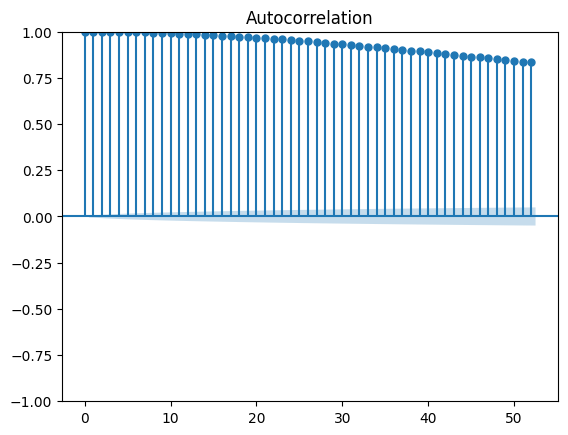

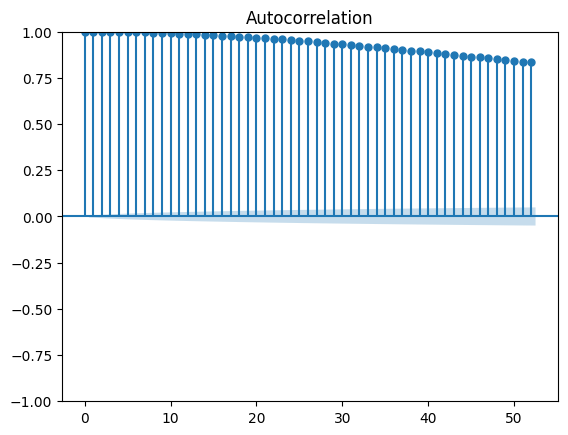

In [21]:
plot_acf(pr_ds)

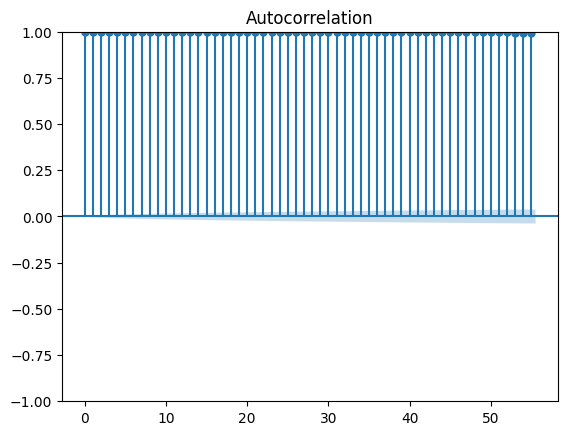

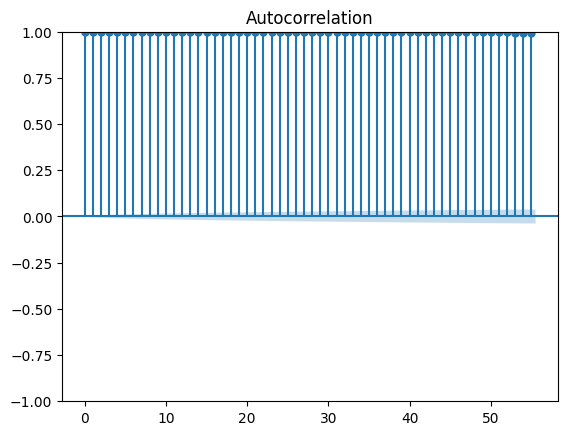

In [26]:
plot_acf(jp_ds)

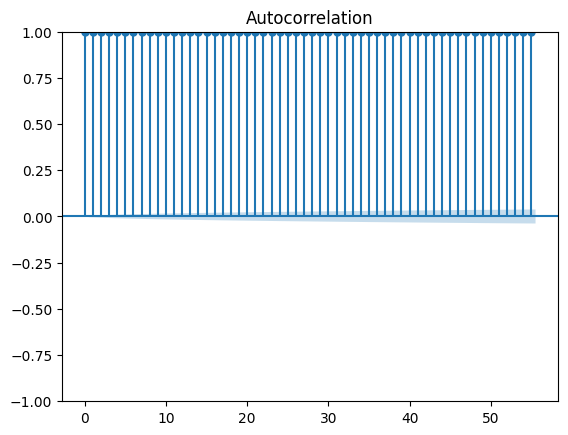

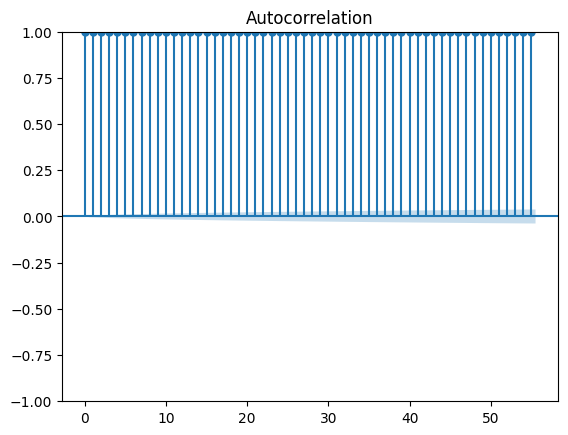

In [27]:
plot_acf(frk_ds)

In [22]:
# then load the boxcar filtered data, repeat the analysis

In [24]:
#load the SCHA filtered signal for Point Reyes 
#use Eli's SCHA filter subtide that I then subtracted the 40 day box car from
bcptreyes=pd.read_csv("/global/scratch/users/jennaisrael/time_varying_data/tide_gauge_data/bcfiltered_SCHA_subtide_ptreyes.csv")
dtformat = '%Y-%m-%dT%H:%M:%S'
bcptreyes['datetime'] = pd.to_datetime(bcptreyes['datetime'],format=dtformat)
bcpr_filt=bcptreyes[['datetime','box_40d_filt']].rename(columns={"box_40d_filt": "Residual"}).dropna()
bcpr_filt.set_index("datetime",inplace=True)
bcpr_filt

,Residual
datetime,
2012-02-12 01:30:00,0.057819
2012-02-12 02:00:00,0.059018
2012-02-12 02:30:00,0.060316
2012-02-12 03:00:00,0.061613
2012-02-12 03:30:00,0.062910
...,...
2023-11-19 20:30:00,-0.110012
2023-11-19 21:00:00,-0.109173
2023-11-19 21:30:00,-0.108133


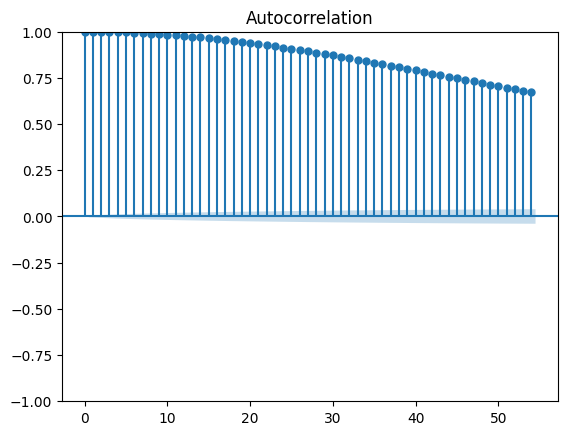

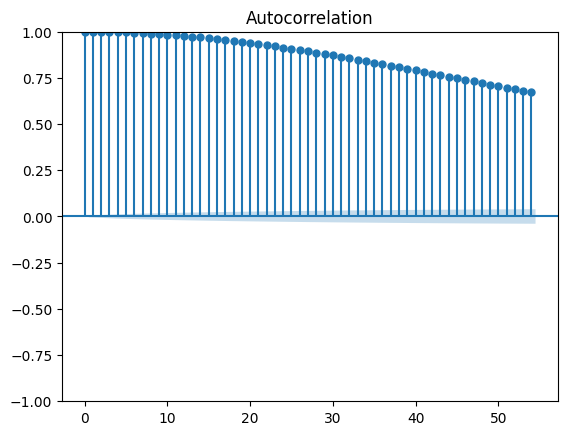

In [25]:
plot_acf(bcpr_filt)

In [ ]:
# # autocorrelation
# acorrpr = correlate(bcpr_filt,pr_ds)
# alagspr = correlation_lags(len(pr_ds),len(pr_ds))
# print('Lag of max autocorrelation for Point Reyes is '+ str(alagspr[acorrpr.argmax()]*0.5)+ ' hours')
# acorrjp = correlate(jp_ds,jp_ds)
# alagsjp = correlation_lags(len(jp_ds),len(jp_ds))
# print('Lag of max autocorrelation for Jersey Point is '+ str(alagsjp[acorrjp.argmax()]*0.25)+ ' hours')
# acorrfrk = correlate(frk_ds,frk_ds)
# alagsfrk = correlation_lags(len(frk_ds),len(frk_ds))
# print('Lag of max autocorrelation for Franks Tract is '+ str(alagsfrk[acorrfrk.argmax()]*0.25)+ ' hours')

In [28]:
jp=pd.read_csv('/global/scratch/users/jennaisrael/time_varying_data/dmsdatastore/salinity/jp_tidal_40dbc_filt.csv')
jp['datetime']=pd.to_datetime(jp['datetime'],format=dtformat)
jp.set_index("datetime",inplace=True)

frk=pd.read_csv('/global/scratch/users/jennaisrael/time_varying_data/dmsdatastore/salinity/frk_tidal_40dbc_filt.csv')
frk['datetime']=pd.to_datetime(frk['datetime'],format=dtformat)
frk.set_index("datetime",inplace=True)

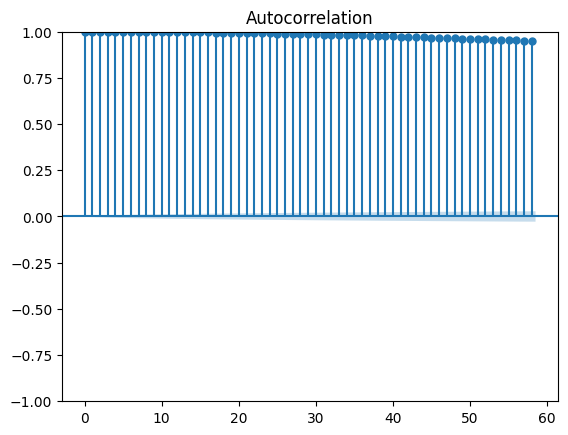

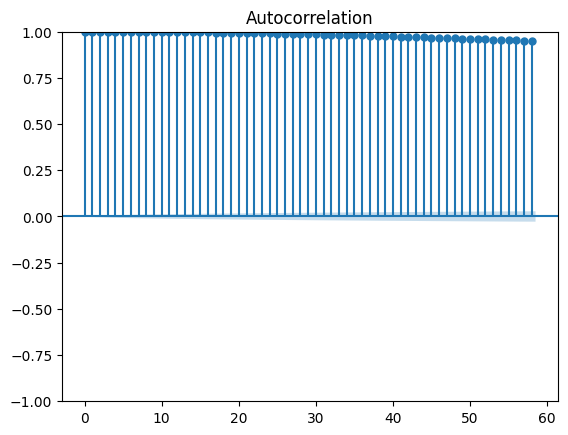

In [29]:
plot_acf(jp)

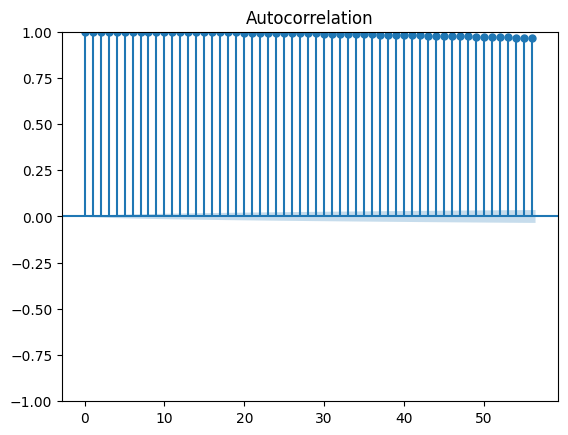

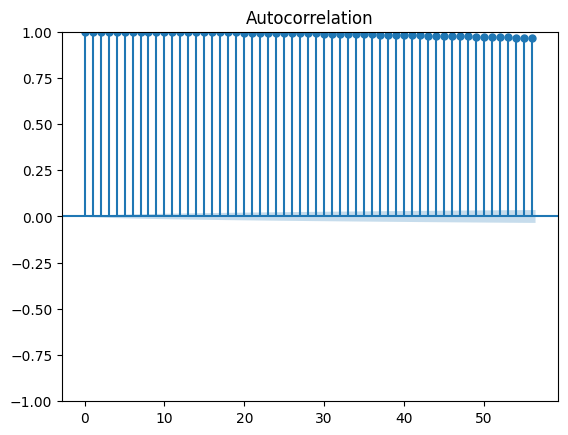

In [30]:
plot_acf(frk)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import ccf
from statsmodels.tsa.statespace.sarimax import SARIMAX

# x: "input"/driver series (pd.Series with DateTimeIndex)
# y: response series (same index/frequency)
# Make sure aligned and no gaps
df = pd.concat([pr_trim.rename("x"), jp_trim.rename("y")], axis=1).dropna()
x = df["x"]
y = df["y"]

# Optional: remove mean
x = x - x.mean()
y = y - y.mean()

# 1) Fit ARIMA/SARIMA to x (the prewhitening model)
# Start simple; tune order as needed
model_x = SARIMAX(x, order=(2,0,2), seasonal_order=(0,0,0,0), trend='n',
                  enforce_stationarity=False, enforce_invertibility=False)
res_x = model_x.fit(disp=False)

# 2) Prewhiten x: residuals ~ white-ish
ex = res_x.resid

# 3) Filter y with SAME ARMA coefficients used for x
# In statsmodels, easiest practical approach:
# fit y with x-model fixed structure, then take one-step-ahead innovations
# (approximate same whitening filter)
model_y = SARIMAX(y, order=(2,0,2), seasonal_order=(0,0,0,0), trend='n',
                  enforce_stationarity=False, enforce_invertibility=False)
res_y = model_y.filter(res_x.params)   # apply x-fitted params to y model
ey = res_y.resid

# 4) Compute cross-correlation of whitened series
# ccf gives non-negative lags corr(ex_t, ey_{t+k})
max_lag = 100
cc = ccf(ex, ey)[:max_lag+1]

# Approx significance band (white-noise assumption after whitening)
N = np.isfinite(ex).sum()
conf = 1.96 / np.sqrt(N)

lags = np.arange(0, max_lag+1)
plt.figure(figsize=(8,4))
plt.stem(lags, cc, basefmt=" ")
plt.axhline(0, color='k', lw=1)
plt.axhline(conf, color='r', ls='--')
plt.axhline(-conf, color='r', ls='--')
plt.xlabel("Lag k (corr(ex_t, ey_{t+k}))")
plt.ylabel("Prewhitened CCF")
plt.title("Prewhitened Cross-Correlation")
plt.tight_layout()
plt.show()